# Visualize Ground Truth SURFACE_AT_LINE Annotations

This notebook visualizes non-sign bbox annotations (e.g. `SURFACE_AT_LINE`) from the ground truth files.
These represent individual tablet sides (obverse, reverse, etc.) within a photo, and serve as
the ground truth for validating `divide_tablet_photo`.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Add project root to path
sys.path.insert(0, str(Path('..').resolve()))

ANNOTATIONS_DIR = Path('/home/jebediahc/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations/annotations')
IMGS_DIR = Path('/home/jebediahc/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations/imgs')

# Non-sign label types to visualize
NON_SIGN_LABELS = {'SURFACE_AT_LINE'}

## 1. Parse annotations and collect statistics

In [2]:
def parse_annotation_file(filepath):
    """
    Parse a gt_*.txt annotation file.
    Returns a list of dicts with keys: x, y, w, h, label
    """
    entries = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) >= 5:
                try:
                    x, y, w, h = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
                    label = parts[4].strip()
                    entries.append({'x': x, 'y': y, 'w': w, 'h': h, 'label': label})
                except ValueError:
                    pass
    return entries


def get_fragment_id(gt_filename):
    """Extract fragment ID from gt_*.txt filename."""
    name = Path(gt_filename).stem  # e.g. 'gt_BM.40295'
    return name[3:]  # Remove 'gt_' prefix


# Parse all annotation files
all_fragments = {}  # fragment_id -> {'surface_boxes': [...], 'sign_count': int}

for gt_file in sorted(ANNOTATIONS_DIR.glob('gt_*.txt')):
    fragment_id = get_fragment_id(gt_file.name)
    entries = parse_annotation_file(gt_file)
    
    surface_boxes = [e for e in entries if e['label'] in NON_SIGN_LABELS]
    sign_count = sum(1 for e in entries if e['label'] not in NON_SIGN_LABELS)
    
    all_fragments[fragment_id] = {
        'surface_boxes': surface_boxes,
        'sign_count': sign_count,
        'gt_file': gt_file
    }

total = len(all_fragments)
with_surface = {fid: v for fid, v in all_fragments.items() if v['surface_boxes']}
without_surface = {fid: v for fid, v in all_fragments.items() if not v['surface_boxes']}

print(f"Total annotation files: {total}")
print(f"With SURFACE_AT_LINE:   {len(with_surface)} ({len(with_surface)/total*100:.1f}%)")
print(f"Without SURFACE_AT_LINE:{len(without_surface)} ({len(without_surface)/total*100:.1f}%)")

# Distribution of surface count per fragment
side_counts = defaultdict(int)
for v in with_surface.values():
    n = len(v['surface_boxes'])
    side_counts[n] += 1

print("\nDistribution of SURFACE_AT_LINE count per fragment:")
for k in sorted(side_counts):
    print(f"  {k} side(s): {side_counts[k]} fragments")

Total annotation files: 947
With SURFACE_AT_LINE:   530 (56.0%)
Without SURFACE_AT_LINE:417 (44.0%)

Distribution of SURFACE_AT_LINE count per fragment:
  1 side(s): 64 fragments
  2 side(s): 365 fragments
  3 side(s): 76 fragments
  4 side(s): 24 fragments
  7 side(s): 1 fragments


In [3]:
# Check which fragments have corresponding images
img_extensions = ['.jpg', '.jpeg', '.png']

def find_image(fragment_id):
    for ext in img_extensions:
        p = IMGS_DIR / f"{fragment_id}{ext}"
        if p.exists():
            return p
    return None

fragments_with_image = {fid: v for fid, v in with_surface.items() if find_image(fid) is not None}
fragments_no_image = {fid: v for fid, v in with_surface.items() if find_image(fid) is None}

print(f"Fragments with SURFACE_AT_LINE AND corresponding image: {len(fragments_with_image)}")
print(f"Fragments with SURFACE_AT_LINE but NO image:            {len(fragments_no_image)}")
if fragments_no_image:
    print(f"  (first 10 missing: {list(fragments_no_image.keys())[:10]})")

Fragments with SURFACE_AT_LINE AND corresponding image: 530
Fragments with SURFACE_AT_LINE but NO image:            0


## 2. Visualize sample images with SURFACE_AT_LINE bboxes

In [4]:
def visualize_surface_boxes(fragment_id, fragment_data, ax=None, max_display_width=900):
    """
    Draw SURFACE_AT_LINE bounding boxes on the tablet image.
    Returns the annotated image as numpy array, or None if image not found.
    """
    img_path = find_image(fragment_id)
    if img_path is None:
        return None
    
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    h, w = img_rgb.shape[:2]
    
    # Scale down for display if too large
    scale = min(1.0, max_display_width / w)
    display_w = int(w * scale)
    display_h = int(h * scale)
    display_img = cv2.resize(img_rgb, (display_w, display_h))
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(display_w / 100, display_h / 100))
    
    ax.imshow(display_img)
    ax.set_title(f"{fragment_id}  ({len(fragment_data['surface_boxes'])} sides, {fragment_data['sign_count']} signs)",
                 fontsize=9)
    ax.axis('off')
    
    # Draw each SURFACE_AT_LINE box
    colors = ['#FF3333', '#3399FF', '#33CC33', '#FF9900', '#CC33FF']
    for i, box in enumerate(fragment_data['surface_boxes']):
        x = box['x'] * scale
        y = box['y'] * scale
        bw = box['w'] * scale
        bh = box['h'] * scale
        color = colors[i % len(colors)]
        rect = patches.Rectangle((x, y), bw, bh,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x + 4, y + 16, f"SURFACE {i+1}",
                fontsize=7, color=color,
                bbox=dict(facecolor='white', alpha=0.6, pad=1, edgecolor='none'))
    
    return display_img

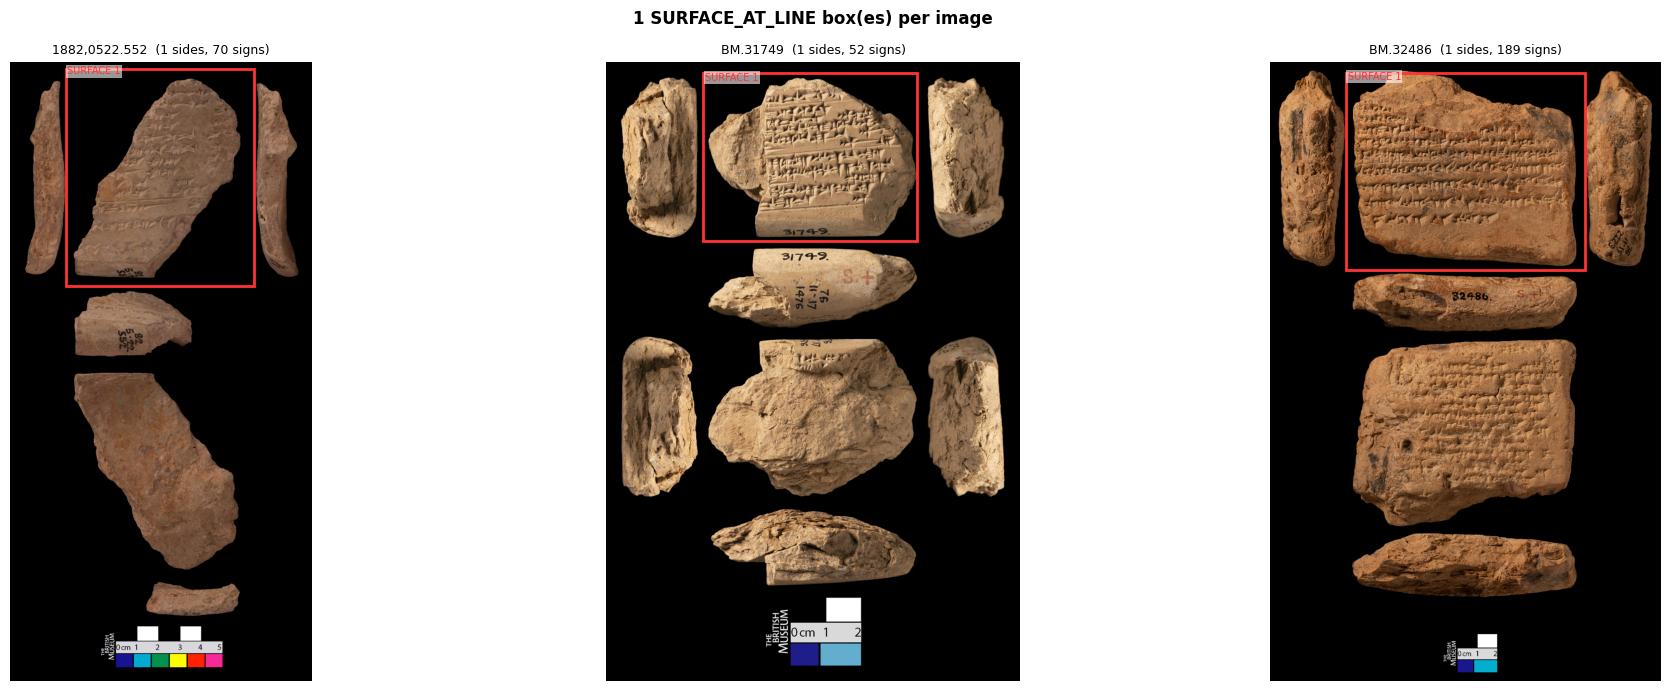

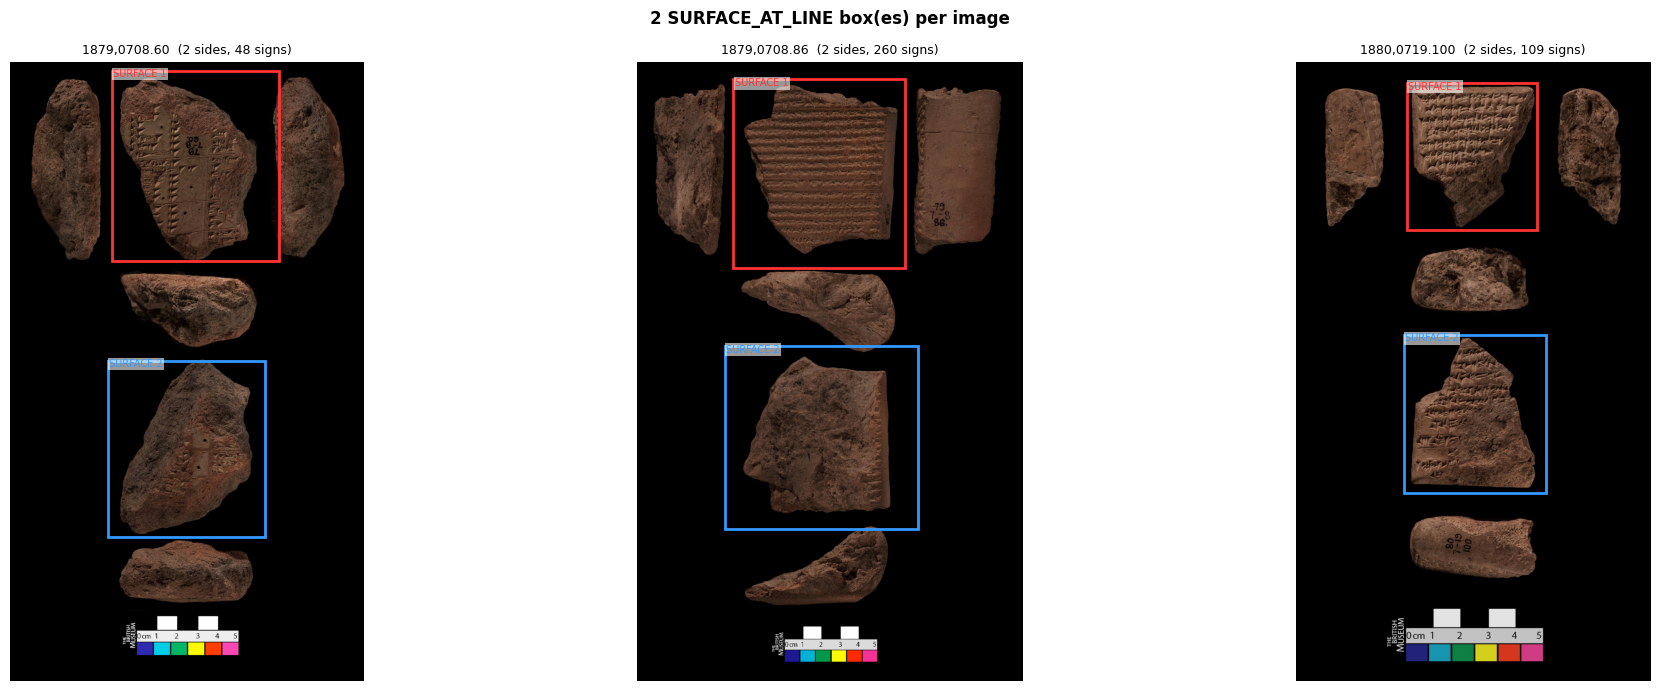

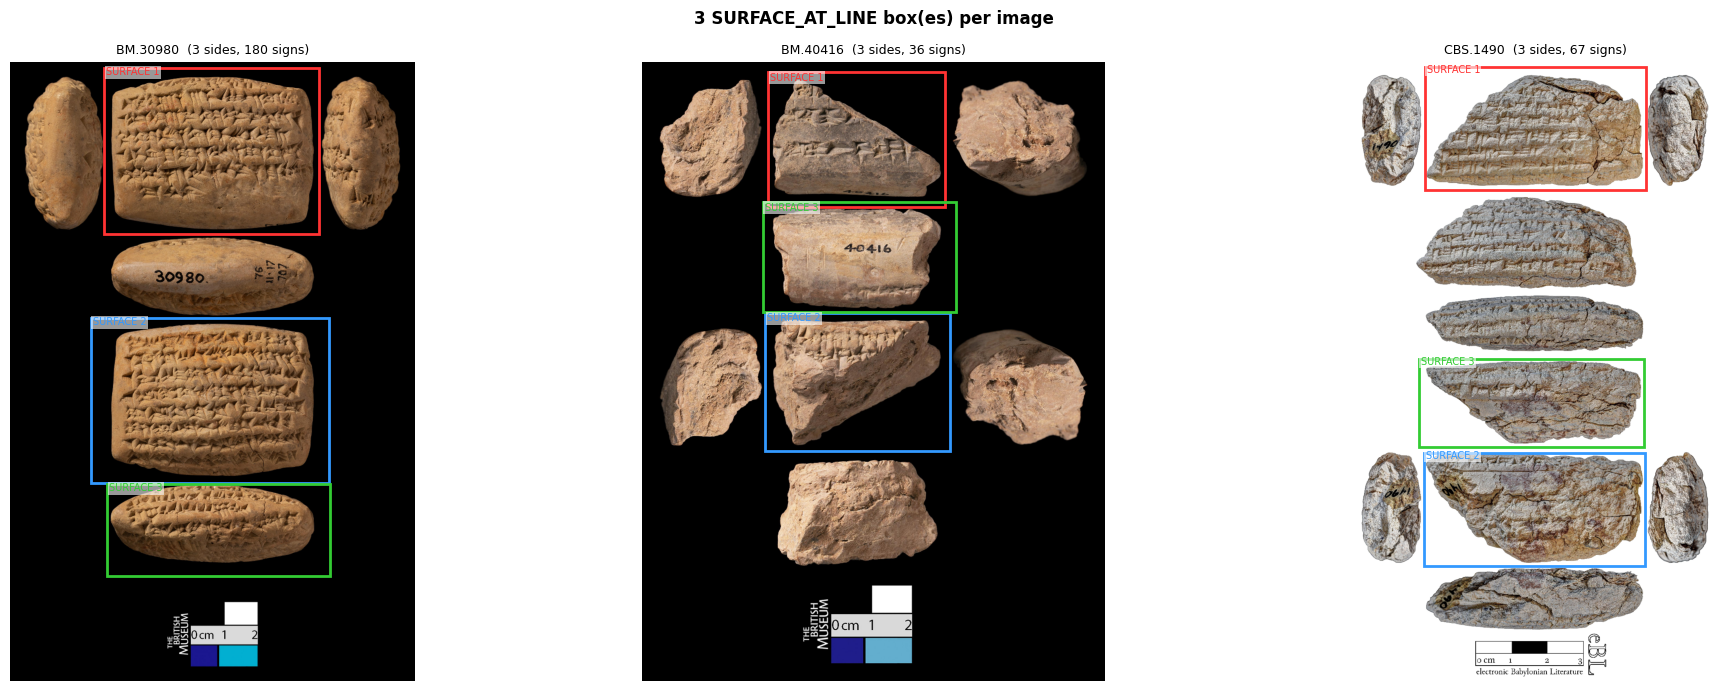

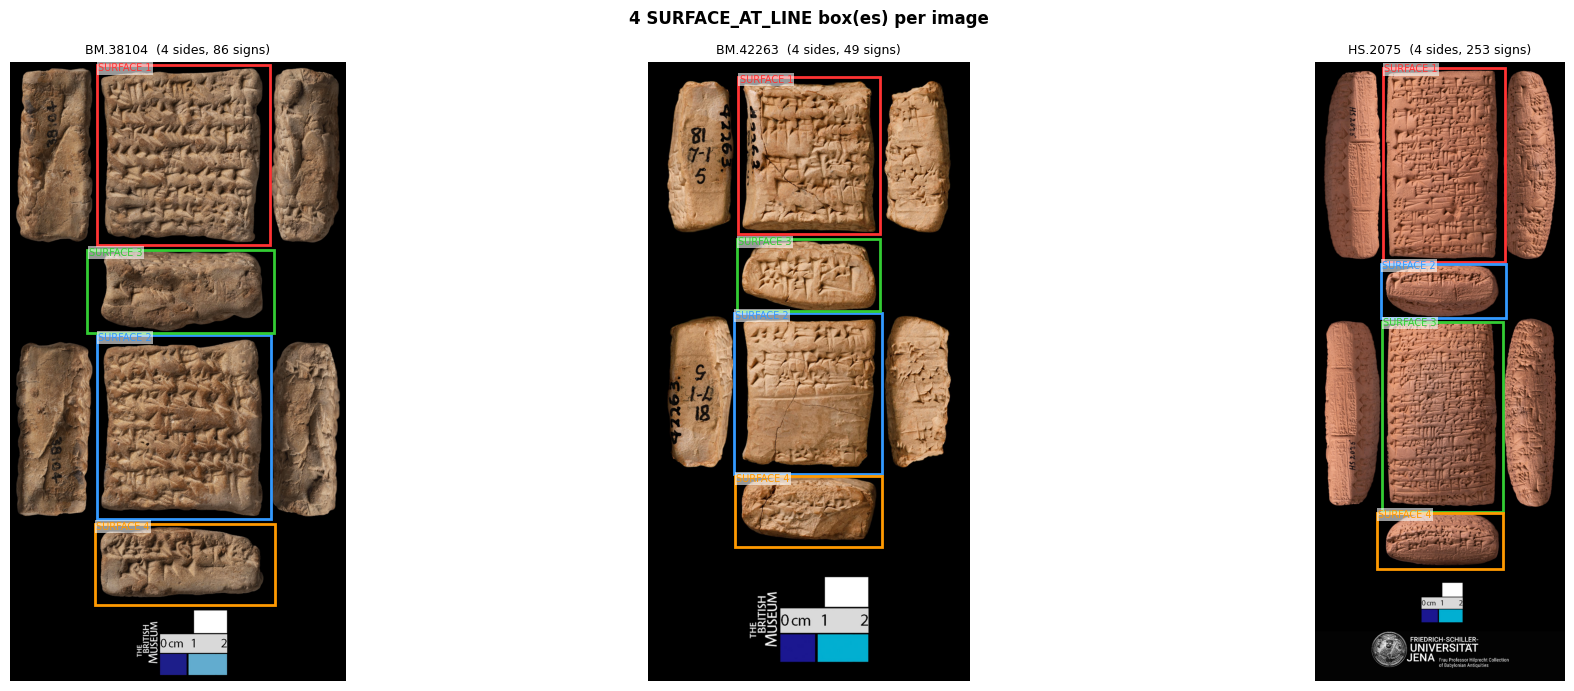

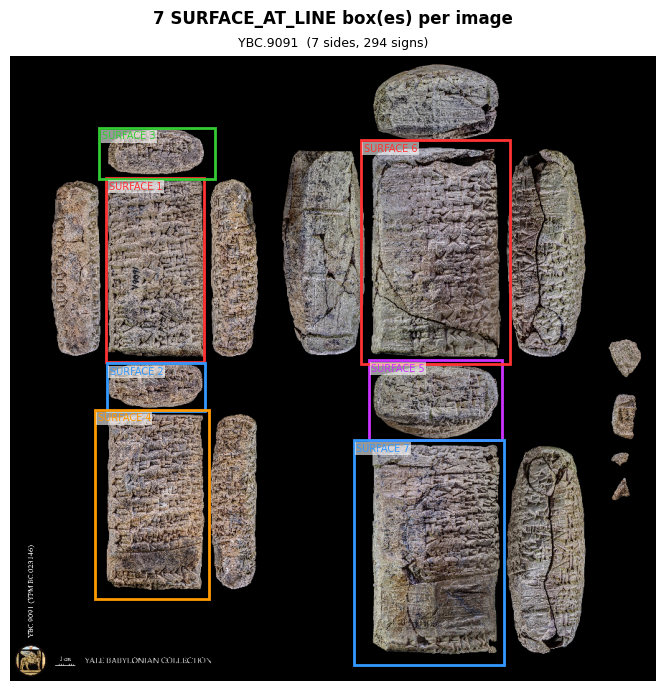

In [5]:
# Visualize samples grouped by number of sides
# Show up to 3 examples for each side count

samples_per_group = 3

# Group fragments by side count
groups = defaultdict(list)
for fid, v in fragments_with_image.items():
    n = len(v['surface_boxes'])
    groups[n].append(fid)

for n_sides in sorted(groups.keys()):
    fids = groups[n_sides][:samples_per_group]
    ncols = len(fids)
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 7))
    if ncols == 1:
        axes = [axes]
    
    fig.suptitle(f"{n_sides} SURFACE_AT_LINE box(es) per image", fontsize=12, fontweight='bold')
    
    for ax, fid in zip(axes, fids):
        visualize_surface_boxes(fid, fragments_with_image[fid], ax=ax)
    
    plt.tight_layout()
    plt.show()

## 3. Inspect specific fragments

Use this cell to look at a specific fragment by ID.

Fragment: BM.40295
  SURFACE_AT_LINE boxes (2):
    [1] x=119, y=93, w=1063, h=1349
    [2] x=1241, y=45, w=1083, h=1379
  Sign annotations: 31


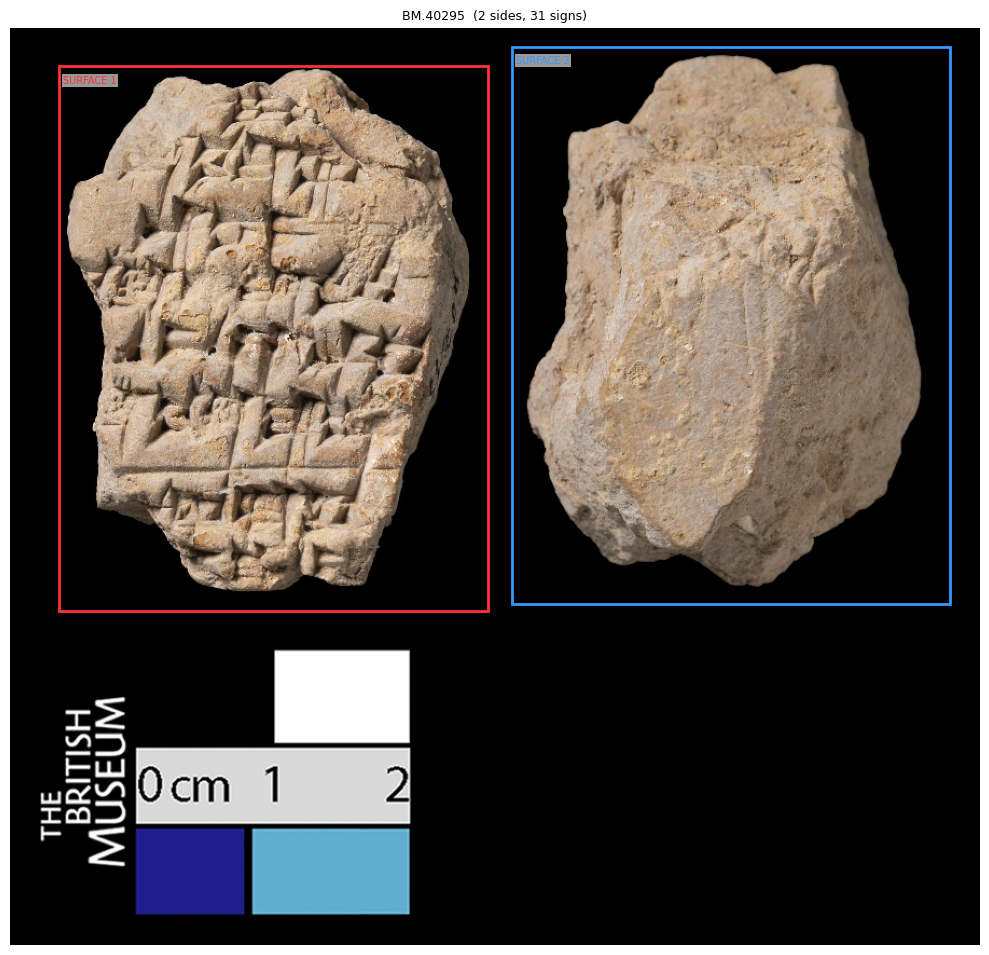

In [6]:
# Change this to inspect any fragment
INSPECT_ID = 'BM.40295'

if INSPECT_ID in all_fragments:
    data = all_fragments[INSPECT_ID]
    print(f"Fragment: {INSPECT_ID}")
    print(f"  SURFACE_AT_LINE boxes ({len(data['surface_boxes'])}):") 
    for i, box in enumerate(data['surface_boxes']):
        print(f"    [{i+1}] x={box['x']}, y={box['y']}, w={box['w']}, h={box['h']}")
    print(f"  Sign annotations: {data['sign_count']}")
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    visualize_surface_boxes(INSPECT_ID, data, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print(f"Fragment '{INSPECT_ID}' not found in annotations.")

## 4. Summary: Coverage of SURFACE_AT_LINE annotations

This section summarizes what we know about the ground truth coverage,
relevant for the validation study.

In [7]:
print("=" * 60)
print("SURFACE_AT_LINE Ground Truth Coverage Summary")
print("=" * 60)
print(f"Total annotated fragments:           {total}")
print(f"With SURFACE_AT_LINE:                {len(with_surface)} ({len(with_surface)/total*100:.1f}%)")
print(f"  ... and with available image:      {len(fragments_with_image)}")
print(f"  ... missing image:                 {len(fragments_no_image)}")
print()
print("Side count distribution (usable for validation):")
for k in sorted(side_counts):
    n_with_img = sum(1 for fid in groups.get(k, []) if fid in fragments_with_image)
    print(f"  {k} side(s): {side_counts[k]} fragments  (with image: {n_with_img})")
print()
print("Note: Fragments WITHOUT SURFACE_AT_LINE may be single-side photos")
print("where only sign-level annotations were added. They cannot be used")
print("as ground truth for segmentation validation without manual review.")

SURFACE_AT_LINE Ground Truth Coverage Summary
Total annotated fragments:           947
With SURFACE_AT_LINE:                530 (56.0%)
  ... and with available image:      530
  ... missing image:                 0

Side count distribution (usable for validation):
  1 side(s): 64 fragments  (with image: 64)
  2 side(s): 365 fragments  (with image: 365)
  3 side(s): 76 fragments  (with image: 76)
  4 side(s): 24 fragments  (with image: 24)
  7 side(s): 1 fragments  (with image: 1)

Note: Fragments WITHOUT SURFACE_AT_LINE may be single-side photos
where only sign-level annotations were added. They cannot be used
as ground truth for segmentation validation without manual review.
